# Compare two model benchmark JSON files

This notebook compares two benchmark result files from `chatbot_service`, summarizes aggregate metrics, and shows a decision-oriented dashboard.

It includes raw metrics, a metric-by-metric winner table, and per-question deltas so you can choose a model faster.

Update the two input paths below if you want to compare different files.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 5)

BASE_DIR = Path.cwd()
if not (BASE_DIR / "deepseek-1.json").exists() and (BASE_DIR / "chatbot_service").exists():
    BASE_DIR = BASE_DIR / "chatbot_service"

MODEL_A_PATH = BASE_DIR / "deepseek-1.json"
MODEL_B_PATH = BASE_DIR / "llama3.1.json"

MODEL_A_NAME = MODEL_A_PATH.stem
MODEL_B_NAME = MODEL_B_PATH.stem

In [2]:
def load_benchmark(path: Path) -> dict:
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)

def details_frame(payload: dict, model_name: str) -> pd.DataFrame:
    rows = []
    for item in payload.get("details", []):
        score = item.get("score", {})
        rows.append({
            "model": model_name,
            "question": item.get("question"),
            "answer": item.get("answer"),
            "precision": score.get("precision"),
            "recall": score.get("recall"),
            "f1": score.get("f1"),
            "groundedness": item.get("groundedness"),
            "latency": item.get("latency"),
            "num_citations": item.get("num_citations"),
        })
    return pd.DataFrame(rows)

model_a = load_benchmark(MODEL_A_PATH)
model_b = load_benchmark(MODEL_B_PATH)

df_a = details_frame(model_a, MODEL_A_NAME)
df_b = details_frame(model_b, MODEL_B_NAME)

df_a.head()

,model,question,answer,precision,recall,f1,groundedness,latency,num_citations
0,deepseek-1,Which employees are declining?,All employees listed in the knowledge are curr...,1.0,1.000000,1.000,1.0,149.947630,24
1,deepseek-1,Which employees are improving?,"The employees who are improving, based on the ...",1.0,1.000000,1.000,1.0,51.920692,6
2,deepseek-1,Which employees are high performers?,The high performers are:\n\n1. Employee Ho Nam...,1.0,0.454545,0.625,1.0,48.335865,5
3,deepseek-1,Who are average?,Average performance level employees are those ...,1.0,1.000000,1.000,1.0,53.281541,9
4,deepseek-1,Which excellent employees are declining?,"Based on the provided Knowledge, the following...",1.0,1.000000,1.000,1.0,78.790077,8


In [3]:
summary = pd.DataFrame([
    {
        "model": MODEL_A_NAME,
        "k": model_a.get("k"),
        "workspace": model_a.get("workspace"),
        "avg_f1": model_a.get("avg_f1"),
        "avg_groundedness": model_a.get("avg_groundedness"),
        "avg_latency": model_a.get("avg_latency"),
        "num_questions": len(model_a.get("details", [])),
    },
    {
        "model": MODEL_B_NAME,
        "k": model_b.get("k"),
        "workspace": model_b.get("workspace"),
        "avg_f1": model_b.get("avg_f1"),
        "avg_groundedness": model_b.get("avg_groundedness"),
        "avg_latency": model_b.get("avg_latency"),
        "num_questions": len(model_b.get("details", [])),
    },
])

summary

,model,k,workspace,avg_f1,avg_groundedness,avg_latency,num_questions
0,deepseek-1,5,productivity,0.745040,0.92,55.712510,10
1,llama3.1,5,productivity,0.591865,0.92,23.188319,10


In [4]:
comparison = df_a.merge(
    df_b,
    on="question",
    how="inner",
    suffixes=(f"_{MODEL_A_NAME}", f"_{MODEL_B_NAME}"),
)

comparison["f1_delta"] = comparison[f"f1_{MODEL_A_NAME}"] - comparison[f"f1_{MODEL_B_NAME}"]
comparison["latency_delta"] = comparison[f"latency_{MODEL_A_NAME}"] - comparison[f"latency_{MODEL_B_NAME}"]
comparison["groundedness_delta"] = comparison[f"groundedness_{MODEL_A_NAME}"] - comparison[f"groundedness_{MODEL_B_NAME}"]

comparison.sort_values("f1_delta", ascending=False)[[
    "question",
    f"f1_{MODEL_A_NAME}",
    f"f1_{MODEL_B_NAME}",
    "f1_delta",
    f"latency_{MODEL_A_NAME}",
    f"latency_{MODEL_B_NAME}",
    "latency_delta",
]]

,question,f1_deepseek-1,f1_llama3.1,f1_delta,latency_deepseek-1,latency_llama3.1,latency_delta
1,Which employees are improving?,1.000000,0.000000,1.000000,51.920692,15.704374,36.216318
7,Những nhân viên nào đang giảm năng suất?,1.000000,0.500000,0.500000,40.071567,24.617916,15.453651
4,Which excellent employees are declining?,1.000000,0.857143,0.142857,78.790077,24.157133,54.632944
0,Which employees are declining?,1.000000,1.000000,0.000000,149.947630,51.973050,97.974580
2,Which employees are high performers?,0.625000,0.625000,0.000000,48.335865,20.313330,28.022535
3,Who are average?,1.000000,1.000000,0.000000,53.281541,29.439421,23.842120
5,Give team overview,1.000000,1.000000,0.000000,28.128407,14.116484,14.011923
6,Ai đang tăng năng suất?,0.000000,0.000000,0.000000,39.531650,21.879376,17.652274
8,Who needs intervention?,0.714286,0.714286,0.000000,30.647846,16.941723,13.706123
9,Which employees got promoted?,0.111111,0.222222,-0.111111,36.469826,12.740382,23.729444


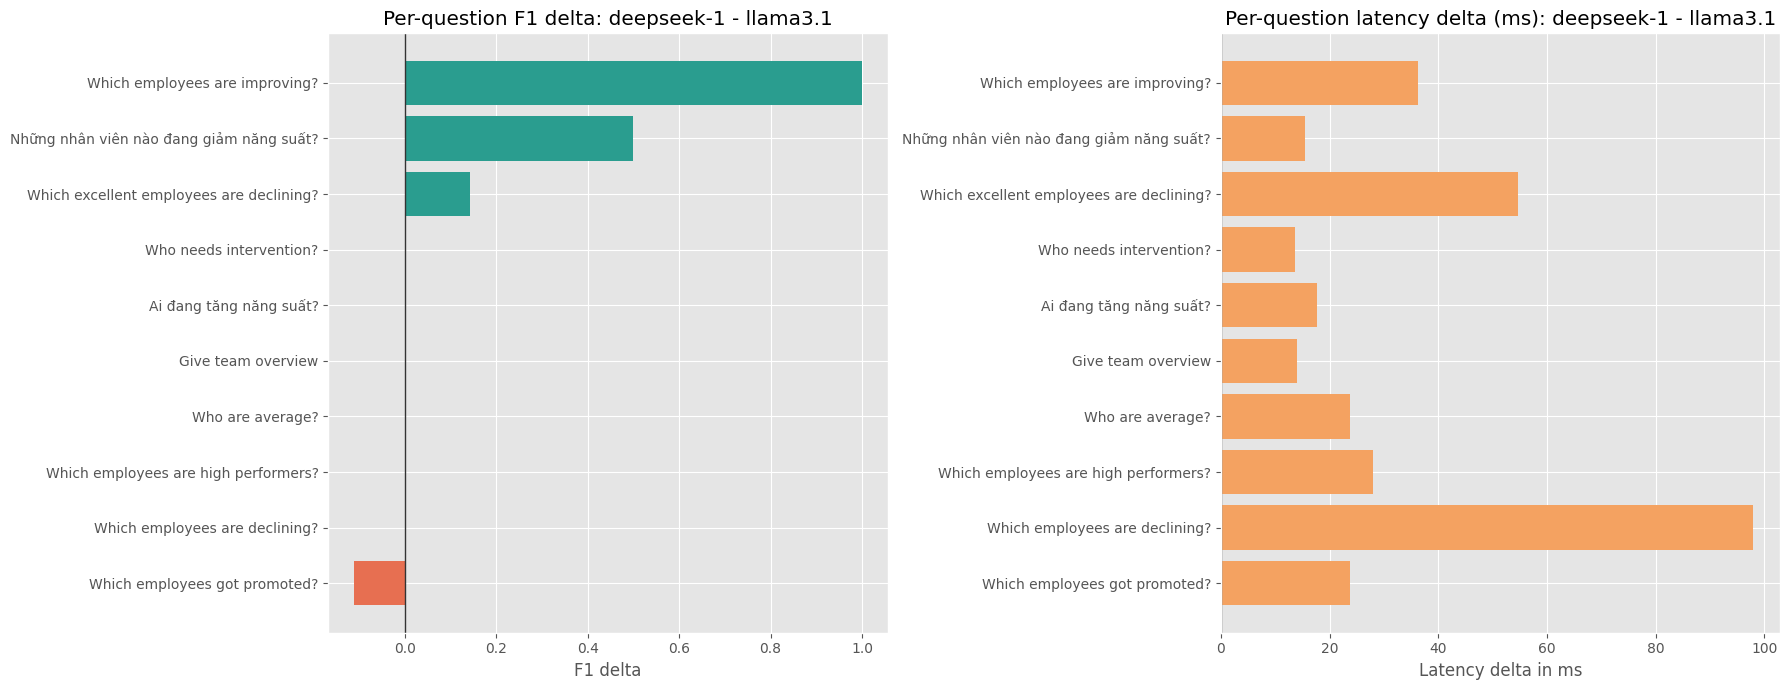

In [5]:
question_scores = comparison[[
    "question",
    f"f1_{MODEL_A_NAME}",
    f"f1_{MODEL_B_NAME}",
    "f1_delta",
    f"latency_{MODEL_A_NAME}",
    f"latency_{MODEL_B_NAME}",
    "latency_delta",
]].sort_values("f1_delta")

question_scores["winner"] = question_scores["f1_delta"].map(
    lambda delta: MODEL_A_NAME if delta > 0 else MODEL_B_NAME if delta < 0 else "tie"
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

f1_colors = ["#2a9d8f" if value > 0 else "#e76f51" if value < 0 else "#777777" for value in question_scores["f1_delta"]]
axes[0].barh(question_scores["question"], question_scores["f1_delta"], color=f1_colors)
axes[0].axvline(0, color="#333333", linewidth=1)
axes[0].set_title(f"Per-question F1 delta: {MODEL_A_NAME} - {MODEL_B_NAME}")
axes[0].set_xlabel("F1 delta")
axes[0].set_ylabel("")

latency_colors = ["#457b9d" if value < 0 else "#f4a261" if value > 0 else "#777777" for value in question_scores["latency_delta"]]
axes[1].barh(question_scores["question"], question_scores["latency_delta"], color=latency_colors)
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_title(f"Per-question latency delta (ms): {MODEL_A_NAME} - {MODEL_B_NAME}")
axes[1].set_xlabel("Latency delta in ms")
axes[1].set_ylabel("")

plt.tight_layout()

Recommended model: deepseek-1
Metric winners: deepseek-1 (2 wins), llama3.1 (2 wins)


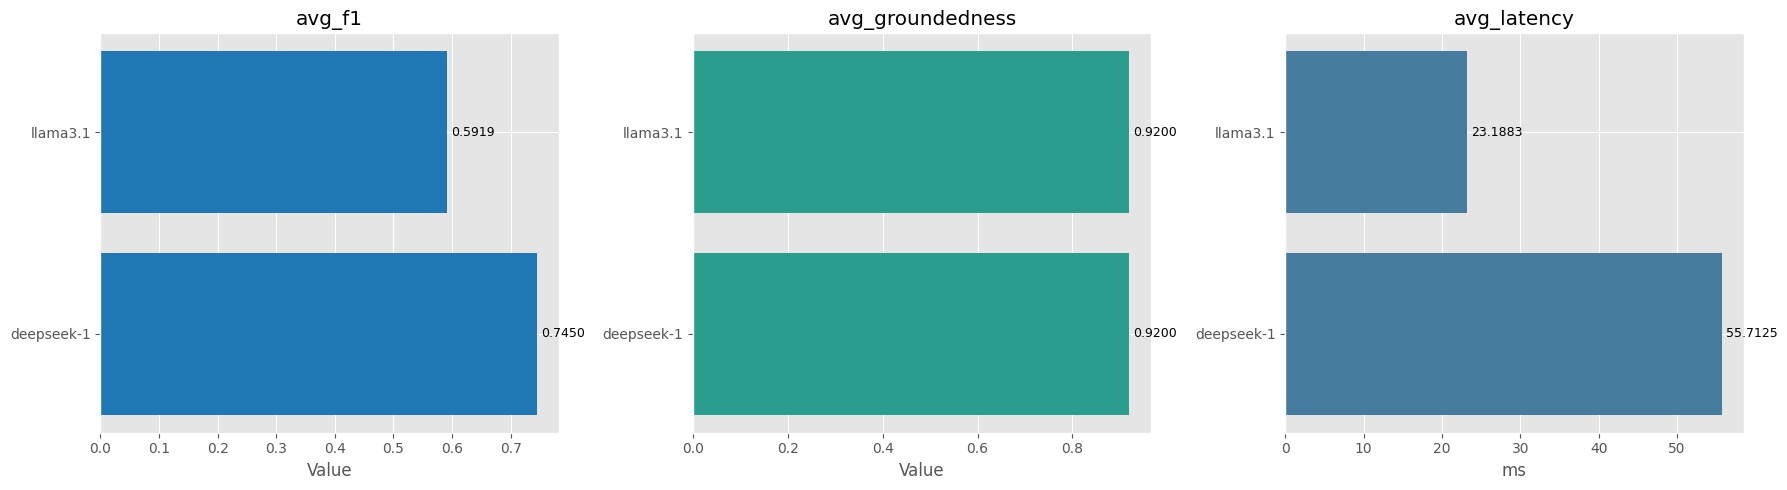

In [6]:
def build_raw_dashboard(frame: pd.DataFrame) -> pd.DataFrame:
    dashboard = frame.copy()
    dashboard["f1_win"] = dashboard["avg_f1"] == dashboard["avg_f1"].max()
    dashboard["groundedness_win"] = dashboard["avg_groundedness"] == dashboard["avg_groundedness"].max()
    dashboard["latency_win"] = dashboard["avg_latency"] == dashboard["avg_latency"].min()
    dashboard["wins"] = dashboard[["f1_win", "groundedness_win", "latency_win"]].sum(axis=1)
    return dashboard.sort_values(["wins", "avg_f1"], ascending=[False, False]).reset_index(drop=True)


dashboard = build_raw_dashboard(summary)

display_columns = dashboard[[
    "model",
    "wins",
    "avg_f1",
    "avg_groundedness",
    "avg_latency",
    "f1_win",
    "groundedness_win",
    "latency_win",
]]

display_columns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(dashboard["model"], dashboard["avg_f1"], color="#1f77b4")
axes[0].set_title("avg_f1")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("")
axes[1].barh(dashboard["model"], dashboard["avg_groundedness"], color="#2a9d8f")
axes[1].set_title("avg_groundedness")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("")
axes[2].barh(dashboard["model"], dashboard["avg_latency"], color="#457b9d")
axes[2].set_title("avg_latency")
axes[2].set_xlabel("ms")
axes[2].set_ylabel("")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
winner = dashboard.iloc[0]["model"]
winners_text = ", ".join([f"{row.model} ({int(row.wins)} wins)" for row in dashboard.itertuples()])
print(f"Recommended model: {winner}")
print(f"Metric winners: {winners_text}")

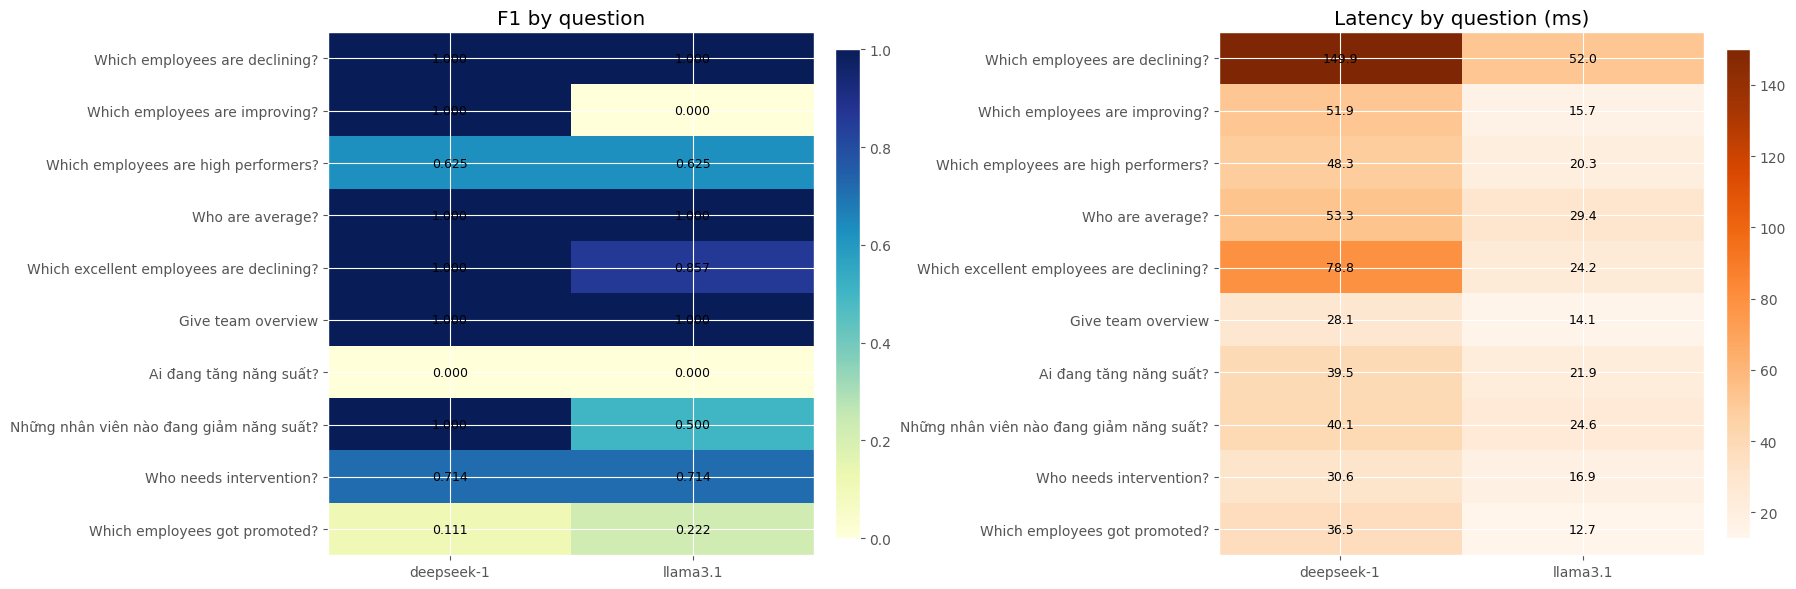

In [7]:
question_order = comparison["question"].tolist()

f1_cols = [f"f1_{MODEL_A_NAME}", f"f1_{MODEL_B_NAME}"]
latency_cols = [f"latency_{MODEL_A_NAME}", f"latency_{MODEL_B_NAME}"]

f1_table = comparison.set_index("question")[f1_cols].loc[question_order]
latency_table = comparison.set_index("question")[latency_cols].loc[question_order]

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, 0.55 * len(question_order))))

im_f1 = axes[0].imshow(f1_table.values, aspect="auto", cmap="YlGnBu")
axes[0].set_title("F1 by question")
axes[0].set_xticks(range(len(f1_cols)))
axes[0].set_xticklabels([MODEL_A_NAME, MODEL_B_NAME], rotation=0)
axes[0].set_yticks(range(len(question_order)))
axes[0].set_yticklabels(question_order)
for row_idx in range(f1_table.shape[0]):
    for col_idx in range(f1_table.shape[1]):
        value = f1_table.iat[row_idx, col_idx]
        axes[0].text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im_f1, ax=axes[0], fraction=0.046, pad=0.04)

im_latency = axes[1].imshow(latency_table.values, aspect="auto", cmap="Oranges")
axes[1].set_title("Latency by question (ms)")
axes[1].set_xticks(range(len(latency_cols)))
axes[1].set_xticklabels([MODEL_A_NAME, MODEL_B_NAME], rotation=0)
axes[1].set_yticks(range(len(question_order)))
axes[1].set_yticklabels(question_order)
for row_idx in range(latency_table.shape[0]):
    for col_idx in range(latency_table.shape[1]):
        value = latency_table.iat[row_idx, col_idx]
        axes[1].text(col_idx, row_idx, f"{value:.1f}", ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im_latency, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()

In [8]:
# Final conclusion based on Cell 6 (question-level deltas) and Cell 7 (raw dashboard)
f1_a_better = int((question_scores["f1_delta"] > 0).sum())
f1_b_better = int((question_scores["f1_delta"] < 0).sum())
f1_tie = int((question_scores["f1_delta"] == 0).sum())

lat_a_faster = int((question_scores["latency_delta"] < 0).sum())
lat_b_faster = int((question_scores["latency_delta"] > 0).sum())
lat_tie = int((question_scores["latency_delta"] == 0).sum())

dashboard_top = dashboard.iloc[0]
dashboard_second = dashboard.iloc[1] if len(dashboard) > 1 else dashboard.iloc[0]

if dashboard_top["wins"] > dashboard_second["wins"]:
    final_model = dashboard_top["model"]
    reason = "more metric wins in raw dashboard"
else:
    # Tie-breaker with question-level quality first, then speed
    if f1_a_better > f1_b_better:
        final_model = MODEL_A_NAME
        reason = "tie on dashboard wins, but better F1 on more questions"
    elif f1_b_better > f1_a_better:
        final_model = MODEL_B_NAME
        reason = "tie on dashboard wins, but better F1 on more questions"
    elif lat_a_faster > lat_b_faster:
        final_model = MODEL_A_NAME
        reason = "tie on dashboard and F1 question wins, but faster on more questions"
    elif lat_b_faster > lat_a_faster:
        final_model = MODEL_B_NAME
        reason = "tie on dashboard and F1 question wins, but faster on more questions"
    else:
        final_model = dashboard_top["model"]
        reason = "full tie, fallback to dashboard ordering"

print("=== Conclusion based on Cell 6 and Cell 7 ===")
print(f"Question-level F1 wins  -> {MODEL_A_NAME}: {f1_a_better}, {MODEL_B_NAME}: {f1_b_better}, tie: {f1_tie}")
print(f"Question-level speed wins -> {MODEL_A_NAME}: {lat_a_faster}, {MODEL_B_NAME}: {lat_b_faster}, tie: {lat_tie}")
print(f"Raw dashboard wins -> {MODEL_A_NAME}: {int(dashboard.loc[dashboard['model'] == MODEL_A_NAME, 'wins'].iloc[0])}, {MODEL_B_NAME}: {int(dashboard.loc[dashboard['model'] == MODEL_B_NAME, 'wins'].iloc[0])}")
print(f"Final recommended model: {final_model} ({reason})")

=== Conclusion based on Cell 6 and Cell 7 ===
Question-level F1 wins  -> deepseek-1: 3, llama3.1: 1, tie: 6
Question-level speed wins -> deepseek-1: 0, llama3.1: 10, tie: 0
Raw dashboard wins -> deepseek-1: 2, llama3.1: 2
Final recommended model: deepseek-1 (tie on dashboard wins, but better F1 on more questions)


In [9]:
output_path = BASE_DIR / f"{MODEL_A_NAME}_vs_{MODEL_B_NAME}_comparison.csv"
comparison.to_csv(output_path, index=False)
output_path

PosixPath('/Users/trantuanminhkhoa/DO_AN_CHUYEN_NGANH/chatbot_service/deepseek-1_vs_llama3.1_comparison.csv')